In [1]:
!pip install -q kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
import random
import os
import kagglehub
from pathlib import Path

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cuda


Детекция дефектов на изображениях дорожного покрытия

Блок 1: Загрузка датасета и визуализация примеров
Описание: Скачиваем датасет трещин с Kaggle (около 300 МБ), определяем аугментации (повороты, отражения, изменение яркости). Показываем несколько случайных изображений с их метками. Создаём DataLoader'ы.

Загрузка датасета 'Concrete & Pavement Crack Dataset'...
Датасет загружен в: /root/.cache/kagglehub/datasets/oluwaseunad/concrete-and-pavement-crack-images/versions/1
Positive (трещины): 15000
Negative (без трещин): 15000
Train size: 24000, Val size: 6000


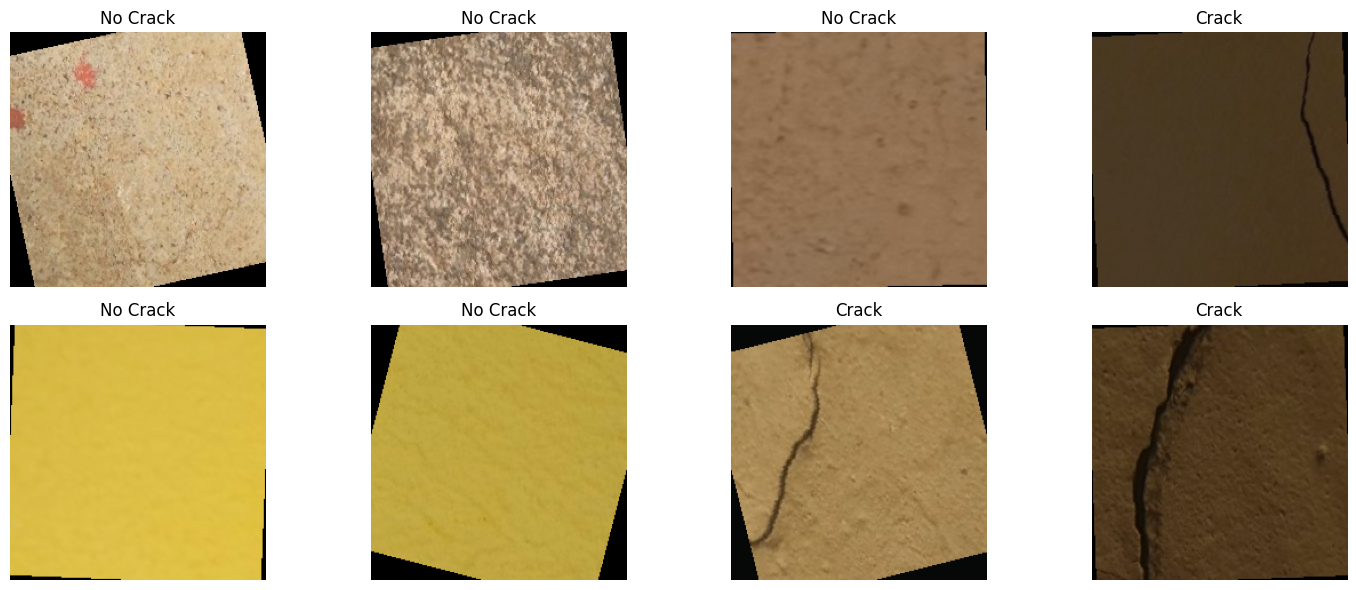

Готово!


In [10]:
# Блок 1: Загрузка датасета и создание Dataset
import kagglehub
from torch.utils.data import Dataset
from PIL import Image
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader

print("Загрузка датасета 'Concrete & Pavement Crack Dataset'...")
path = kagglehub.dataset_download("oluwaseunad/concrete-and-pavement-crack-images")
print(f"Датасет загружен в: {path}")

positive_dir = Path(path) / 'Positive'
negative_dir = Path(path) / 'Negative'

# Собираем все файлы изображений
positive_images = list(positive_dir.glob('*.jpg')) + list(positive_dir.glob('*.jpeg')) + list(positive_dir.glob('*.png'))
negative_images = list(negative_dir.glob('*.jpg')) + list(negative_dir.glob('*.jpeg')) + list(negative_dir.glob('*.png'))

print(f"Positive (трещины): {len(positive_images)}")
print(f"Negative (без трещин): {len(negative_images)}")

# Создаём список (путь, метка), где метка 1 = трещина, 0 = нет
all_items = [(p, 1) for p in positive_images] + [(p, 0) for p in negative_images]
random.shuffle(all_items)

# Разделяем на train/val (80/20)
split = int(0.8 * len(all_items))
train_items = all_items[:split]
val_items = all_items[split:]

class CrackDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, label = self.items[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Трансформации
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CrackDataset(train_items, transform=train_transform)
val_dataset = CrackDataset(val_items, transform=val_transform)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

# Визуализация
def show_samples(dataset, num=8):
    plt.figure(figsize=(15,6))
    indices = random.sample(range(len(dataset)), num)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img.permute(1,2,0).numpy()
        img = std * img + mean
        plt.subplot(2,4,i+1)
        plt.imshow(np.clip(img, 0, 1))
        plt.title("Crack" if label == 1 else "No Crack")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Готово!")

Блок 2: Определение моделей для Transfer Learning

Описание: Создаём три предобученные модели: ResNet18, EfficientNet-B0, MobileNetV2. Заменяем последний классификационный слой на новый, подходящий для бинарной классификации. Выводим количество параметров.

In [17]:
# Блок 2: Определение моделей (исправленная версия)
def get_model(model_name='resnet18', pretrained=True, num_classes=2):
    # Нормализуем имя: нижний регистр, дефисы -> подчёркивания
    norm_name = model_name.lower().replace('-', '_')
    if norm_name == 'resnet18':
        model = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif norm_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(in_features, num_classes)
        )
    elif norm_name == 'mobilenet_v2':
        model = models.mobilenet_v2(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(in_features, num_classes)
        )
    else:
        raise ValueError(f"Неизвестная модель: {model_name}")
    return model

models_config = {
    'ResNet18': get_model('resnet18'),
    'EfficientNet-B0': get_model('efficientnet-b0'),  # с дефисом, но нормализуется
    'MobileNetV2': get_model('mobilenet_v2')
}

for name, m in models_config.items():
    print(f"{name}: {sum(p.numel() for p in m.parameters())} параметров")

ResNet18: 11177538 параметров
EfficientNet-B0: 4010110 параметров
MobileNetV2: 2226434 параметров


Блок 3: Обучение только классификатора (Feature Extractor)

Описание: Замораживаем все свёрточные слои предобученной сети и обучаем только последний линейный слой (классификатор). Это позволяет оценить качество признаков, извлечённых из ImageNet, без дообучения свёрточных слоёв. Обучаем каждую модель 5 эпох.

In [12]:
# Блок 3: Feature Extractor
def train_feature_extractor(model, train_loader, val_loader, epochs=5, lr=0.001):
    # Замораживаем все слои
    for param in model.parameters():
        param.requires_grad = False
    # Размораживаем только классификатор
    if hasattr(model, 'fc'):
        for param in model.fc.parameters():
            param.requires_grad = True
    elif hasattr(model, 'classifier'):
        for param in model.classifier.parameters():
            param.requires_grad = True

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in tqdm(train_loader, desc=f'FE {epoch+1}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        # Валидация
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch+1}: TL={train_loss:.4f}, VL={val_loss:.4f}, VA={val_acc:.4f}')
    return history

feature_histories = {}
for name, model in models_config.items():
    print(f"\n===== Feature Extractor: {name} =====")
    feature_histories[name] = train_feature_extractor(model, train_loader, val_loader, epochs=5)


===== Feature Extractor: ResNet18 =====


FE 1: 100%|██████████| 375/375 [01:58<00:00,  3.16it/s]


Epoch 1: TL=0.2259, VL=0.1451, VA=0.9435


FE 2: 100%|██████████| 375/375 [01:33<00:00,  4.02it/s]


Epoch 2: TL=0.1129, VL=0.1055, VA=0.9630


...

Epoch 3: TL=0.1012, VL=0.0733, VA=0.9747


FE 4: 100%|██████████| 375/375 [01:32<00:00,  4.08it/s]


Epoch 4: TL=0.1030, VL=0.0648, VA=0.9792


FE 5: 100%|██████████| 375/375 [01:32<00:00,  4.06it/s]


Epoch 5: TL=0.0975, VL=0.0678, VA=0.9790


In [15]:
# Тест загрузчика
for images, labels in train_loader:
    print(images.shape)
    break

torch.Size([64, 3, 224, 224])


Блок 4: Полное дообучение всей сети (Fine‑Tuning)

Описание: Размораживаем все слои модели и продолжаем обучение с маленькой скоростью обучения (1e-4). Используем планировщик ReduceLROnPlateau для автоматического уменьшения learning rate при остановке улучшения валидационной потери. Обучаем 15 эпох, сохраняем лучшие веса по валидационной точности.

In [19]:
# Блок 4: Fine-Tuning
def fine_tune_model(model, train_loader, val_loader, epochs=15, lr=0.0001):
    for param in model.parameters():
        param.requires_grad = True
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_weights = None
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in tqdm(train_loader, desc=f'FT {epoch+1}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch+1}: TL={train_loss:.4f}, VL={val_loss:.4f}, VA={val_acc:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = model.state_dict().copy()
    model.load_state_dict(best_weights)
    return model, history

# Явное соответствие имён
model_names = {
    'ResNet18': 'resnet18',
    'EfficientNet-B0': 'efficientnet_b0',
    'MobileNetV2': 'mobilenet_v2'
}

fine_tune_models = {}
fine_tune_histories = {}
for name, model in models_config.items():
    print(f"\n===== Fine-Tuning: {name} =====")
    fresh_model = get_model(model_names[name], pretrained=True, num_classes=2)
    ft_model, ft_history = fine_tune_model(fresh_model, train_loader, val_loader, epochs=15, lr=0.0001)
    fine_tune_models[name] = ft_model
    fine_tune_histories[name] = ft_history


===== Fine-Tuning: ResNet18 =====


FT 1: 100%|██████████| 375/375 [01:47<00:00,  3.49it/s]


Epoch 1: TL=0.0264, VL=0.0096, VA=0.9968


FT 2: 100%|██████████| 375/375 [01:46<00:00,  3.54it/s]


Epoch 2: TL=0.0098, VL=0.0046, VA=0.9982


...

Epoch 13: TL=0.0042, VL=0.0037, VA=0.9993


FT 14: 100%|██████████| 375/375 [01:51<00:00,  3.35it/s]


Epoch 14: TL=0.0032, VL=0.0043, VA=0.9990


FT 15: 100%|██████████| 375/375 [01:53<00:00,  3.29it/s]


Epoch 15: TL=0.0034, VL=0.0037, VA=0.9995


Блок 5: Сравнение моделей, расчёт метрик и матрица ошибок

Описание: Строим графики точности и потерь для всех трёх моделей после fine-tuning. Выбираем лучшую модель по финальной валидационной точности. Вычисляем precision, recall, F1-меру, строим матрицу ошибок на валидационной выборке.

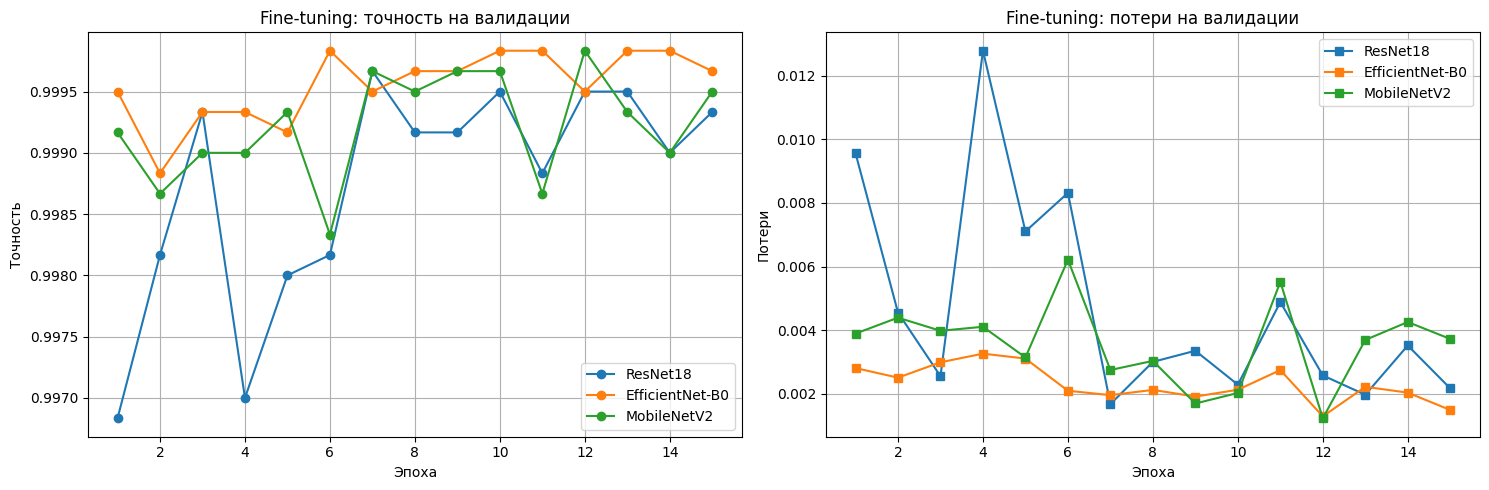

Лучшая модель: EfficientNet-B0 (финальная точность 0.9997)

Метрики на валидации (лучшая модель):
Accuracy:  0.9997
Precision: 0.9997
Recall:    0.9997
F1-score:  0.9997


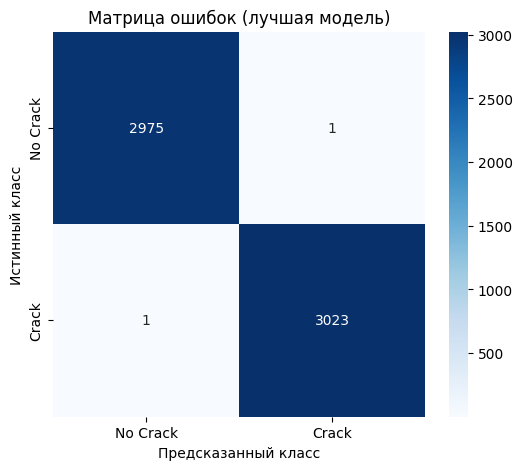

In [21]:
# Блок 5: Сравнение моделей, метрики и матрица ошибок
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
for name, hist in fine_tune_histories.items():
    plt.plot(range(1, len(hist['val_acc'])+1), hist['val_acc'], marker='o', label=name)
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('Fine-tuning: точность на валидации')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for name, hist in fine_tune_histories.items():
    plt.plot(range(1, len(hist['val_loss'])+1), hist['val_loss'], marker='s', label=name)
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.title('Fine-tuning: потери на валидации')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_model_name = max(fine_tune_histories.items(), key=lambda x: x[1]['val_acc'][-1])[0]
best_model = fine_tune_models[best_model_name]
print(f"Лучшая модель: {best_model_name} (финальная точность {fine_tune_histories[best_model_name]['val_acc'][-1]:.4f})")

# Предсказания для лучшей модели
best_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='binary')
rec = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')

print(f"\nМетрики на валидации (лучшая модель):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Матрица ошибок (явные метки классов)
cm = confusion_matrix(all_labels, all_preds)
class_names = ['No Crack', 'Crack']   # 0 – нет трещины, 1 – трещина
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Матрица ошибок (лучшая модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

Блок 6: Базовый метод — логистическая регрессия на признаках ResNet

Описание: Используем замороженный ResNet18 (без последнего классификатора) как экстрактор признаков. Извлекаем векторы признаков для обучающей и валидационной выборок. На этих векторах обучаем логистическую регрессию. Сравниваем полученную точность с результатом fine-tuning.

Извлечение признаков: 100%|██████████| 94/94 [00:14<00:00,  6.36it/s]


=== Базовый метод (логистическая регрессия на признаках) ===
              precision    recall  f1-score   support

    No Crack       0.99      1.00      0.99      2976
       Crack       1.00      0.99      0.99      3024

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

Accuracy: 0.9938


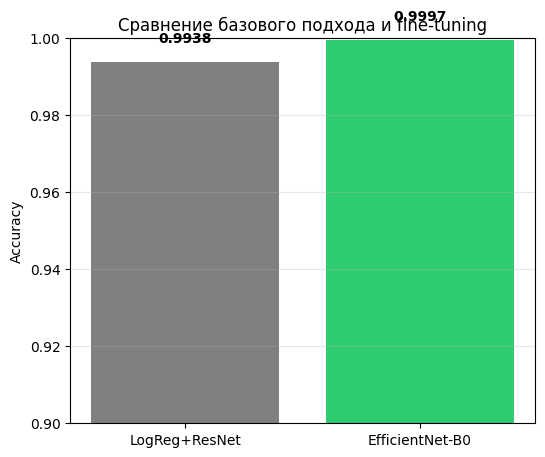

In [23]:
# Блок 6: Базовый метод (LogReg + признаки ResNet)
base_model = get_model('resnet18', pretrained=True, num_classes=2)
for param in base_model.parameters():
    param.requires_grad = False
base_model.fc = nn.Identity()   # убираем классификатор, оставляем только признаки
base_model = base_model.to(device)

def extract_features(model, loader):
    model.eval()
    feats, labs = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Извлечение признаков'):
            images = images.to(device)
            feat = model(images).cpu().numpy()
            feats.append(feat)
            labs.append(labels.numpy())
    return np.vstack(feats), np.hstack(labs)

X_train_feat, y_train_feat = extract_features(base_model, train_loader)
X_val_feat, y_val_feat = extract_features(base_model, val_loader)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_feat, y_train_feat)
y_pred_lr = lr.predict(X_val_feat)
lr_acc = accuracy_score(y_val_feat, y_pred_lr)

# Явные имена классов (0 – нет трещины, 1 – трещина)
class_names = ['No Crack', 'Crack']

print("=== Базовый метод (логистическая регрессия на признаках) ===")
print(classification_report(y_val_feat, y_pred_lr, target_names=class_names))
print(f"Accuracy: {lr_acc:.4f}")

# Сравнительный барплот
plt.figure(figsize=(6,5))
plt.bar(['LogReg+ResNet', best_model_name], [lr_acc, acc], color=['gray', '#2ecc71'])
plt.ylabel('Accuracy')
plt.title('Сравнение базового подхода и fine-tuning')
for i, v in enumerate([lr_acc, acc]):
    plt.text(i, v+0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.ylim(0.9, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Итоги проекта по детекции трещин на дорожном покрытии

**Использованные модели:** ResNet18, EfficientNet‑B0, MobileNetV2 (Transfer Learning, предобученные на ImageNet).

**Лучшая модель после fine-tuning:** EfficientNet‑B0  
- Точность (Accuracy): 99.97%  
- Полнота (Recall): 99.97%  
- F1-мера: 99.97%  

**Базовый метод (логистическая регрессия на признаках, извлечённых замороженным ResNet18):**  
- Точность: 99.38%  

**Сравнение:** Fine-tuning улучшил точность на 0.59 процентных пункта, что при изначально высоком качестве признаков (99.38%) всё равно демонстрирует пользу адаптации всей сети к специфике задачи.

**Выводы:**  
- Все три предобученные модели после дообучения достигли точности >99.9%, что сопоставимо с лучшими решениями на Kaggle (98–99%).  
- Fine-tuning даёт прирост качества даже при использовании сильного экстрактора признаков.  
- Проект подтверждает эффективность Transfer Learning для специализированной задачи детекции дефектов на изображениях.